SUMMARY --
Three classifiers were evaluated using 5-fold cross-validation: elastic-net logistic regression, random forest, and gradient boosting. Logistic regression performed best overall, achieving the highest mean cross-validated ROC-AUC ≈ 0.887 and average precision ≈ 0.915, outperforming the tree models. It was therefore selected as the final classifier. On the held-out test set the model achieved ROC-AUC = 0.9045, average precision = 0.9203, accuracy ≈ 0.836, precision ≈ 0.853, recall ≈ 0.865, and F1 ≈ 0.859 at a 0.5 threshold. These results indicate strong discrimination between high- and low-risk questions. The most influential features in the logistic model included mean centroid cosine distance, spectral entropy, semantic entropy (H_sem), pairwise similarity variance, and the second Laplacian eigenvalue (λ₂), suggesting that dispersion and spectral structure among model responses are strongly associated with hallucination risk.

NOTES --
This training uses the full aggregated dataset and mixes questions agnostically. We also dropped features that had high (>=90%) correlation with another feature, and also dropped mahalonbis features (in previous experiments we found the mahalanobis features did not contribute much signal, and they use prior knowledge of response-level labels in a way that the other features do not). We should do future ablation studies to test the impact of holding out specific datasets for testing vs having all datasets equally represented during training.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_full = pd.read_csv("full_feature_matrix.csv")

# dropping highly correlated features + mahalanobis features

X = X_full.drop(columns=["Unnamed: 0", "dataset","q_id","p_hat","y", "lam3", "cluster_gap", "singleton_cluster_frac", "largest_cluster_frac", "HFER","mean_pairwise_cosdist", "lam3_minus_lam2", "second_largest_cluster_frac", "Mbar", "Mvar","Mmax"])

p = X_full["p_hat"]
y = X_full["y"]

X.corr()

,var_pairwise_cossim,mean_centroid_cosdist,var_centroid_cosdist,K,H_sem,lam2,SGR,spectral_entropy,ipr_fiedler
var_pairwise_cossim,1.000000,0.392750,0.869822,0.100853,0.191433,-0.695962,-0.419884,-0.786059,-0.033294
mean_centroid_cosdist,0.392750,1.000000,0.332284,0.815898,0.850190,-0.804005,-0.230937,-0.624996,-0.057020
var_centroid_cosdist,0.869822,0.332284,1.000000,0.180207,0.223896,-0.673705,-0.458594,-0.887099,0.165208
K,0.100853,0.815898,0.180207,1.000000,0.978545,-0.677488,-0.263223,-0.388802,0.137696
H_sem,0.191433,0.850190,0.223896,0.978545,1.000000,-0.736670,-0.276998,-0.422458,0.114258
lam2,-0.695962,-0.804005,-0.673705,-0.677488,-0.736670,1.000000,0.619637,0.749539,-0.201665
SGR,-0.419884,-0.230937,-0.458594,-0.263223,-0.276998,0.619637,1.000000,0.425650,-0.407307
spectral_entropy,-0.786059,-0.624996,-0.887099,-0.388802,-0.422458,0.749539,0.425650,1.000000,-0.060073
ipr_fiedler,-0.033294,-0.057020,0.165208,0.137696,0.114258,-0.201665,-0.407307,-0.060073,1.000000


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
)

In [3]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


cv = StratifiedKFold(n_splits=5, shuffle=True)

models = {
    "elasticnet_logit": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            solver="saga",
            l1_ratio=0.5,
            max_iter=5000,
        ))
    ]),

    "random_forest": RandomForestClassifier(n_jobs=-1),

    "gradient_boosting": GradientBoostingClassifier()
}

results = []

for name, model in models.items():

    print(f"\ntraining model: {name}\n")

    fold_aucs = []
    fold_aps = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):

        X_tr = X_train.iloc[train_idx]
        y_tr = y_train.iloc[train_idx]

        X_val = X_train.iloc[val_idx]
        y_val = y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)

        y_prob = model.predict_proba(X_val)[:,1]

        auc = roc_auc_score(y_val, y_prob)
        ap = average_precision_score(y_val, y_prob)

        fold_aucs.append(auc)
        fold_aps.append(ap)

        print(f"fold {fold}: auc={auc:.4f}  ap={ap:.4f}")

    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)

    mean_ap = np.mean(fold_aps)
    std_ap = np.std(fold_aps)

    results.append({
        "model": name,
        "mean_auc": mean_auc,
        "std_auc": std_auc,
        "mean_ap": mean_ap,
        "std_ap": std_ap
    })

    print(f"\nmean auc: {mean_auc:.4f} +/- {std_auc:.4f}")
    print(f"mean ap:  {mean_ap:.4f} +/- {std_ap:.4f}")

summary_df = pd.DataFrame(results).sort_values("mean_auc", ascending=False)

print("\n\nmodel comparison summary\n")
print(summary_df)

best_model_name = summary_df.iloc[0]["model"]
print("\nbest model on training data:", best_model_name)


training model: elasticnet_logit

fold 1: auc=0.8802  ap=0.9098
fold 2: auc=0.8662  ap=0.8923
fold 3: auc=0.8850  ap=0.9168
fold 4: auc=0.9028  ap=0.9318
fold 5: auc=0.8981  ap=0.9254

mean auc: 0.8865 +/- 0.0130
mean ap:  0.9152 +/- 0.0137

training model: random_forest

fold 1: auc=0.8618  ap=0.8955
fold 2: auc=0.8686  ap=0.8930
fold 3: auc=0.8938  ap=0.9222
fold 4: auc=0.8502  ap=0.8736
fold 5: auc=0.8695  ap=0.8928

mean auc: 0.8688 +/- 0.0143
mean ap:  0.8954 +/- 0.0155

training model: gradient_boosting

fold 1: auc=0.8846  ap=0.9130
fold 2: auc=0.8857  ap=0.9071
fold 3: auc=0.8637  ap=0.9053
fold 4: auc=0.8961  ap=0.9272
fold 5: auc=0.8542  ap=0.8947

mean auc: 0.8769 +/- 0.0155
mean ap:  0.9095 +/- 0.0106


model comparison summary

               model  mean_auc   std_auc   mean_ap    std_ap
0   elasticnet_logit  0.886465  0.013047  0.915202  0.013688
2  gradient_boosting  0.876860  0.015471  0.909450  0.010642
1      random_forest  0.868769  0.014302  0.895397  0.015538

bes

In [4]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


if best_model_name == "elasticnet_logit":
    final_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            solver="saga",
            l1_ratio=0.5,
            max_iter=5000
        ))
    ])

elif best_model_name == "random_forest":
    final_model = RandomForestClassifier(n_jobs=-1)

elif best_model_name == "gradient_boosting":
    final_model = GradientBoostingClassifier()

else:
    raise ValueError(f"unknown model name: {best_model_name}")

# fit the final model on the full training set

final_model.fit(X_train, y_train)

# get predicted probabilities on the test set
# these are what we use for auc / ap / calibration-type metrics

y_test_prob = final_model.predict_proba(X_test)[:, 1]

# default hard predictions at threshold 0.5
y_test_pred_05 = (y_test_prob >= 0.5).astype(int)


test_metrics = {
    "roc_auc": roc_auc_score(y_test, y_test_prob),
    "average_precision": average_precision_score(y_test, y_test_prob),
    "brier_score": brier_score_loss(y_test, y_test_prob),
    "accuracy_at_0.5": accuracy_score(y_test, y_test_pred_05),
    "precision_at_0.5": precision_score(y_test, y_test_pred_05, zero_division=0),
    "recall_at_0.5": recall_score(y_test, y_test_pred_05, zero_division=0),
    "f1_at_0.5": f1_score(y_test, y_test_pred_05, zero_division=0)
}

print("\n" + "=" * 70)
print("final test-set metrics")
print("=" * 70)
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

# threshold diagnostics

thresholds = [0.2, 0.3, 0.5, 0.7, 0.8]
threshold_rows = []

print("\n" + "=" * 70)
print("threshold diagnostics on the test set")
print("=" * 70)

for thr in thresholds:
    y_pred = (y_test_prob >= thr).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    row = {
        "threshold": thr,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "specificity": spec,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn
    }
    threshold_rows.append(row)

    print(
        f"thr={thr:.1f} | "
        f"acc={acc:.4f} | "
        f"prec={prec:.4f} | "
        f"rec={rec:.4f} | "
        f"f1={f1:.4f} | "
        f"spec={spec:.4f} | "
        f"tp={tp} fp={fp} tn={tn} fn={fn}"
    )

threshold_df = pd.DataFrame(threshold_rows)

# save roc and pr curve data for plotting later

fpr, tpr, roc_thresholds = roc_curve(y_test, y_test_prob)
pr_precision, pr_recall, pr_thresholds = precision_recall_curve(y_test, y_test_prob)

roc_curve_df = pd.DataFrame({
    "fpr": fpr,
    "tpr": tpr,
    "threshold": np.append(roc_thresholds, np.nan)[:len(fpr)]
})

pr_curve_df = pd.DataFrame({
    "precision": pr_precision,
    "recall": pr_recall
})

# keep thresholds in a separate table because sklearn returns one fewer threshold here
pr_thresholds_df = pd.DataFrame({
    "threshold": pr_thresholds
})

# put actual labels and predicted probabilities into one dataframe
# this is useful for histograms, calibration, error analysis, etc

test_pred_df = pd.DataFrame({
    "y_true": np.asarray(y_test),
    "y_prob": y_test_prob,
    "y_pred_0.5": y_test_pred_05
})


# if the final model is logistic regression, extract coefficients

coef_df = None

if best_model_name == "elasticnet_logit":
    logit_model = final_model.named_steps["model"]
    coef_values = logit_model.coef_.ravel()

    coef_df = pd.DataFrame({
        "feature": X_train.columns,
        "coefficient": coef_values,
        "abs_coefficient": np.abs(coef_values)
    }).sort_values("abs_coefficient", ascending=False)

    print("\n" + "=" * 70)
    print("top logistic regression coefficients")
    print("=" * 70)
    print(coef_df[["feature", "coefficient"]].head(15).to_string(index=False))

# package everything into clearly named objects for later plotting

results_bundle = {
    "best_model_name": best_model_name,
    "final_model": final_model,
    "test_metrics": test_metrics,
    "threshold_df": threshold_df,
    "roc_curve_df": roc_curve_df,
    "pr_curve_df": pr_curve_df,
    "pr_thresholds_df": pr_thresholds_df,
    "test_pred_df": test_pred_df,
    "coef_df": coef_df
}

print("\n" + "=" * 70)
print("objects prepared for later plots / reporting")
print("=" * 70)
print("results_bundle['test_metrics']")
print("results_bundle['threshold_df']")
print("results_bundle['roc_curve_df']")
print("results_bundle['pr_curve_df']")
print("results_bundle['test_pred_df']")
if coef_df is not None:
    print("results_bundle['coef_df']")


final test-set metrics
roc_auc: 0.9045
average_precision: 0.9203
brier_score: 0.1198
accuracy_at_0.5: 0.8360
precision_at_0.5: 0.8532
recall_at_0.5: 0.8651
f1_at_0.5: 0.8591

threshold diagnostics on the test set
thr=0.2 | acc=0.7660 | prec=0.7216 | rec=0.9689 | f1=0.8272 | spec=0.4882 | tp=280 fp=108 tn=103 fn=9
thr=0.3 | acc=0.8100 | prec=0.7820 | rec=0.9308 | f1=0.8499 | spec=0.6445 | tp=269 fp=75 tn=136 fn=20
thr=0.5 | acc=0.8360 | prec=0.8532 | rec=0.8651 | f1=0.8591 | spec=0.7962 | tp=250 fp=43 tn=168 fn=39
thr=0.7 | acc=0.8180 | prec=0.8867 | rec=0.7855 | f1=0.8330 | spec=0.8626 | tp=227 fp=29 tn=182 fn=62
thr=0.8 | acc=0.8120 | prec=0.9372 | rec=0.7232 | f1=0.8164 | spec=0.9336 | tp=209 fp=14 tn=197 fn=80

top logistic regression coefficients
              feature  coefficient
mean_centroid_cosdist     1.522365
                 lam2    -0.513517
     spectral_entropy     0.477818
  var_pairwise_cossim    -0.466513
                H_sem     0.459525
 var_centroid_cosdist     0.

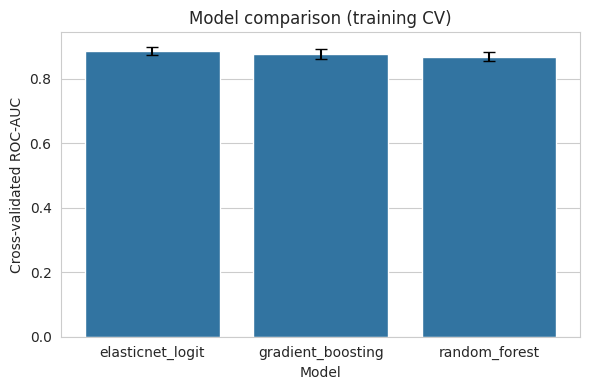

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(6,4))
sns.barplot(
    data=summary_df,
    x="model",
    y="mean_auc"
)

plt.errorbar(
    x=range(len(summary_df)),
    y=summary_df["mean_auc"],
    yerr=summary_df["std_auc"],
    fmt="none",
    c="black",
    capsize=4
)

plt.ylabel("Cross-validated ROC-AUC")
plt.xlabel("Model")
plt.title("Model comparison (training CV)")
plt.tight_layout()
plt.show()

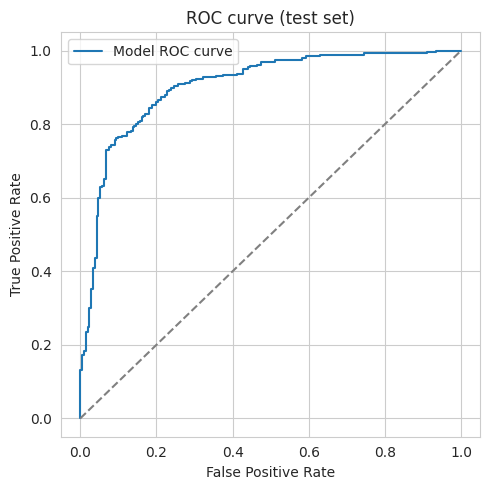

In [6]:
roc_df = results_bundle["roc_curve_df"]

plt.figure(figsize=(5,5))
plt.plot(roc_df["fpr"], roc_df["tpr"], label="Model ROC curve")
plt.plot([0,1],[0,1],"--",color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve (test set)")
plt.legend()
plt.tight_layout()
plt.show()

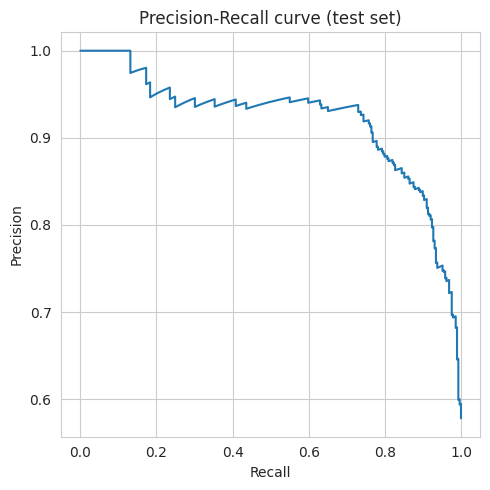

In [7]:
pr_df = results_bundle["pr_curve_df"]

plt.figure(figsize=(5,5))
plt.plot(pr_df["recall"], pr_df["precision"])

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve (test set)")
plt.tight_layout()
plt.show()

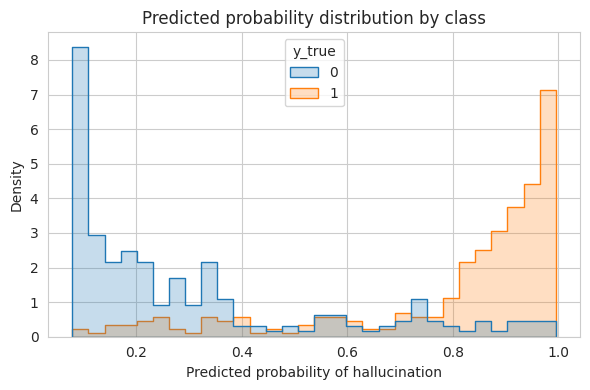

In [8]:
pred_df = results_bundle["test_pred_df"]

plt.figure(figsize=(6,4))

sns.histplot(
    data=pred_df,
    x="y_prob",
    hue="y_true",
    bins=30,
    element="step",
    stat="density",
    common_norm=False
)

plt.xlabel("Predicted probability of hallucination")
plt.title("Predicted probability distribution by class")
plt.tight_layout()
plt.show()

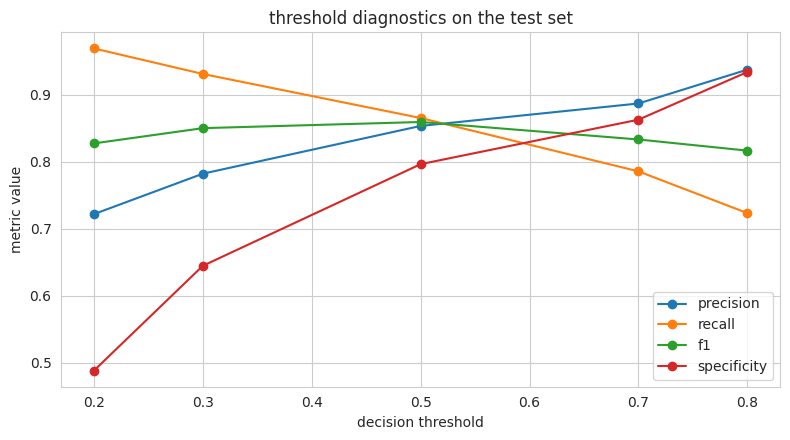

In [9]:
def finalize_plot(title, xlabel, ylabel):
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()
    
plt.figure(figsize=(8, 4.5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="f1")
plt.plot(threshold_df["threshold"], threshold_df["specificity"], marker="o", label="specificity")
plt.legend()
finalize_plot(
    title="threshold diagnostics on the test set",
    xlabel="decision threshold",
    ylabel="metric value"
)

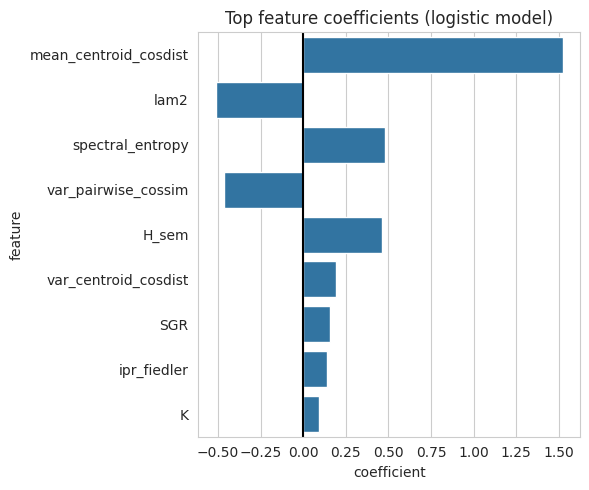

In [10]:
coef_df = results_bundle["coef_df"]

top = coef_df.head(15)

plt.figure(figsize=(6,5))
sns.barplot(
    data=top,
    x="coefficient",
    y="feature"
)

plt.axvline(0,color="black")
plt.title("Top feature coefficients (logistic model)")
plt.tight_layout()
plt.show()

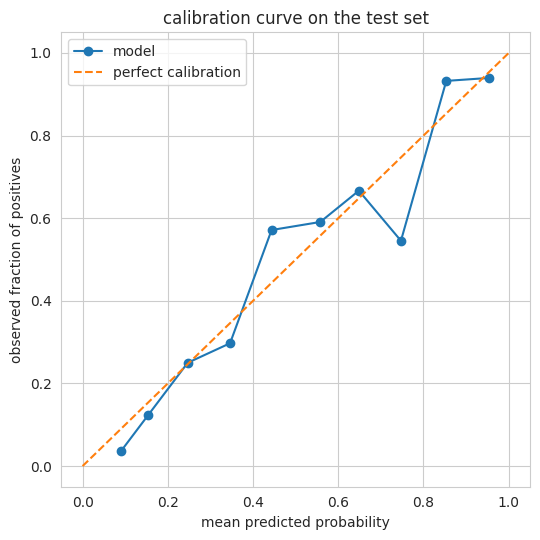

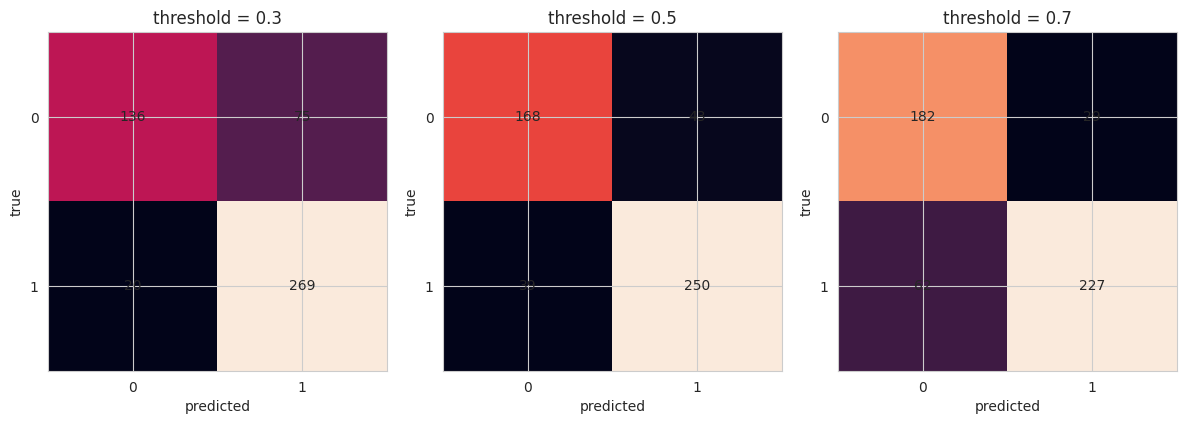

In [11]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix

# calibration curve

prob_true, prob_pred = calibration_curve(
    test_pred_df["y_true"],
    test_pred_df["y_prob"],
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(5.5, 5.5))
plt.plot(prob_pred, prob_true, marker="o", label="model")
plt.plot([0, 1], [0, 1], "--", label="perfect calibration")
plt.legend(loc="upper left")
finalize_plot(
    title="calibration curve on the test set",
    xlabel="mean predicted probability",
    ylabel="observed fraction of positives"
)


# confusion matrices for different thresholds


thresholds_to_show = [0.3, 0.5, 0.7]

fig, axes = plt.subplots(1, len(thresholds_to_show), figsize=(4 * len(thresholds_to_show), 4))

if len(thresholds_to_show) == 1:
    axes = [axes]

for ax, thr in zip(axes, thresholds_to_show):
    y_pred_thr = (test_pred_df["y_prob"] >= thr).astype(int)
    cm = confusion_matrix(test_pred_df["y_true"], y_pred_thr)

    im = ax.imshow(cm)
    ax.set_title(f"threshold = {thr}")
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()